# Week 1.1: Probability & Neural Networks for Digital Twins

## Learning Objectives
- Understand how AI makes predictions using probability
- Learn the basics of neural networks
- Apply these concepts to building a digital twin

## Digital Twin Context
A **digital twin** is a virtual representation of a physical entity (person, object, system). In this series, we'll build a digital twin that can:
- Predict behaviors and preferences
- Understand and respond to language
- Learn from interactions

## Key Insight
> "AI isn't thinking; it's predicting the next number."

This applies to everything from weather prediction to language generation!

---
## Part 1: Probability Foundations

Let's start with the basics: How does AI make predictions?

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


### 1.1 Simple Prediction: Next Number

Let's simulate a digital twin predicting your next action based on historical data.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


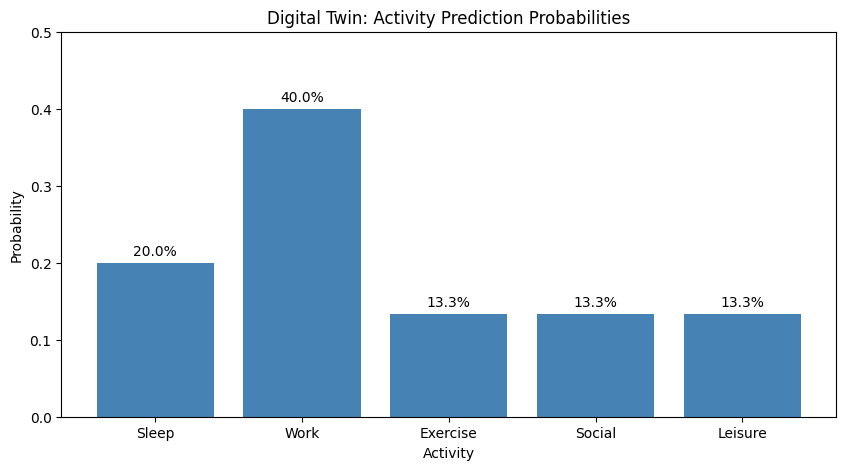

In [2]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

### 🎯 Exercise 1.1 (Easy): Understanding Probabilities

**Task**: Modify the historical activities to represent your own daily routine for 2 weeks (14 days).

**Questions**:
1. Which activity has the highest probability?
2. What does this tell you about the pattern in your data?
3. How would adding more data points affect the predictions?

In [5]:
# YOUR CODE HERE
# Create your own sequence of activities (14 values)
my_activities = [0, 1, 1, 1, 1, 1, 4, 3, 1, 1, 0, 1, 1, 2]  # Replace with your pattern

# Calculate and visualize
my_probs = calculate_probabilities(my_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# YOUR ANALYSIS HERE (write answers as comments)
# 1. Highest probability activity: Work 40.00%
# 2. Pattern insight: I notice that because my pattern is mostly around work, it has the highest percentage. My sleep comes 2nd with 20.00% and my social, exercise and leisure are all equally devided.
# 3. Impact of more data: With more data, I could identify more detailed patterns in my daily activities, such as which days I work the most, how my sleep affects my productivity, and whether my activity balance changes over time.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


### 1.2 Conditional Probability: Context Matters

What if predictions depend on previous activities? This is where context comes in!

In [6]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
        print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



### 🎯 Exercise 1.2 (Intermediate): Markov Chain Prediction

**Task**: Build a simple predictor that uses conditional probabilities to predict the next activity.

**Challenge**: What happens after "Work"? Which activity is most likely?

In [8]:
def predict_next_activity(current_activity, conditional_probs):
    """
    Predict the most likely next activity.

    Args:
        current_activity: Current activity code
        conditional_probs: Dictionary of conditional probabilities

    Returns:
        int: Most likely next activity
    """
    # YOUR CODE HERE
    # Hint: Find the activity with maximum probability given current_activity
    if current_activity not in conditional_probs:
        return None

    next_probs = conditional_probs[current_activity]
    # Complete this function

    return max(next_probs, key=next_probs.get)

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"

current = 1  # Work
sequence = []

for i in range(5):
    predicted = predict_next_activity(current, cond_probs)
    sequence.append(predicted)
    current = predicted

print("Predicted sequence:")
for activity in sequence:
    print(activity_names.get(activity, "Unknown"))

After Work, most likely next: Exercise
Predicted sequence:
Exercise
Work
Exercise
Work
Exercise


---
## Part 2: Neural Networks Basics

Now let's see how neural networks learn to make predictions!

### 2.1 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest neural network - it takes inputs, applies weights, and produces an output.

In [9]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

Probability of exercising: 95.93%
Prediction: Will exercise


### 🎯 Exercise 2.1 (Easy): Feature Engineering

**Task**: Modify the features and observe how the prediction changes.

**Questions**:
1. What happens when sleep hours decrease to 4?
2. What if free time increases to 4 hours?
3. Which feature seems to have the most impact based on the weights?

In [21]:
# YOUR CODE HERE
# Test different feature combinations

test_cases = [
    np.array([4, 2, 0.8]),  # Low sleep
    np.array([7, 4, 0.8]),  # More free time
    np.array([7, 2, 0.3]),  # Low energy
]

# Test each case and analyze results
for i, test_case in enumerate(test_cases, 1):
    prediction = perceptron(test_case, weights, bias)

    print(f"Test Case {i}:")
    print(f"Features: {test_case}")
    print(f"Probability of exercising: {prediction:.2%}")
    print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")
    print()

# 1. What happens when sleep hours decrease to 4?
# When sleep decreases to 4 hours, the probability of exercising decreases, because less sleep has a negative impact on the likelihood of exercising.

# 2. What if free time increases to 4 hours?
# When free time increases to 4 hours, the probability of exercising increases, because having more free time makes it more likely that there is an opportunity to exercise.

# 3. Which feature seems to have the most impact based on the weights?
# Energy seems to have the most impact because it has the highest weight (0.7), compared to free time (0.5) and sleep (0.3).

Test Case 1:
Features: [4.  2.  0.8]
Probability of exercising: 90.55%
Prediction: Will exercise

Test Case 2:
Features: [7.  4.  0.8]
Probability of exercising: 98.46%
Prediction: Will exercise

Test Case 3:
Features: [7.  2.  0.3]
Probability of exercising: 94.32%
Prediction: Will exercise



### 2.2 Training a Simple Neural Network





Let's see how a network learns by adjusting weights!

In [23]:
class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create training data for digital twin
# Features: [day_of_week (0-6), time_of_day (0-23), weather (0-1), mood (0-1)]
# Target: [probability of social activity]

np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

Training neural network...

Epoch 0, Loss: 0.5069
Epoch 100, Loss: 0.1061
Epoch 200, Loss: 0.0863
Epoch 300, Loss: 0.0678
Epoch 400, Loss: 0.0550


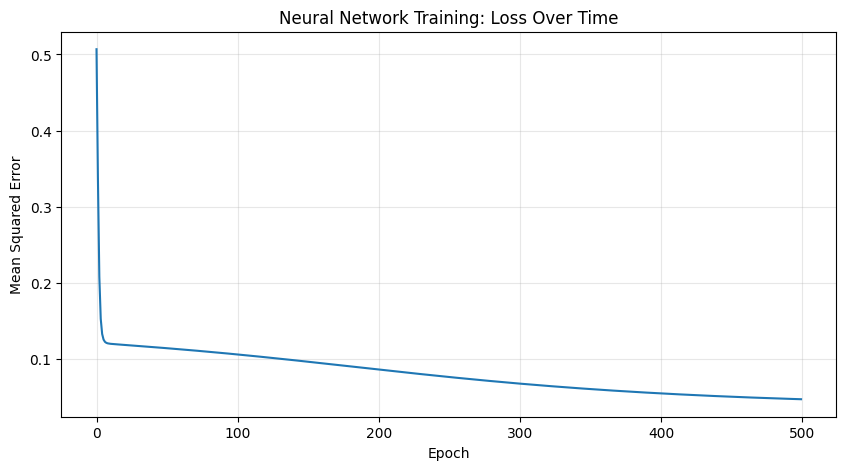


Final loss: 0.0474


In [24]:
# Visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history)
plt.title('Neural Network Training: Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {nn.loss_history[-1]:.4f}")

### 🎯 Exercise 2.2 (Intermediate): Digital Twin Prediction

**Task**: Test the trained network on new scenarios and interpret results.

**Scenarios to test**:
1. Weekend evening (day=6, time=18, weather=0.8, mood=0.9)
2. Weekday morning (day=2, time=8, weather=0.3, mood=0.5)
3. Weekend with bad weather (day=5, time=14, weather=0.2, mood=0.6)

In [26]:
# YOUR CODE HERE
# Normalize inputs (scale to 0-1 range)
def normalize_input(day, time, weather, mood):
    return np.array([[day/7, time/24, weather, mood]])

# Test scenarios
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

# Make predictions and analyze
for name, day, time, weather, mood in scenarios:
    X_test = normalize_input(day, time, weather, mood)
    prediction = nn.predict(X_test)
    print(f"{name}")
    print(f"  Social activity probability: {prediction[0][0]:.2%}\n")

Weekend evening, good weather
  Social activity probability: 72.61%

Weekday morning, poor weather
  Social activity probability: 6.27%

Weekend afternoon, bad weather
  Social activity probability: 22.70%



### 🎯 Exercise 2.3 (Advanced): Improve the Digital Twin

**Task**: Enhance the neural network to make better predictions.

**Challenges**:
1. Add more training data with realistic patterns
2. Experiment with different network architectures (hidden layer size)
3. Try different learning rates
4. Add a second hidden layer
5. Create a visualization showing prediction accuracy

Training data shape: (500, 4)
Target data shape: (500, 1)

Testing architecture: 4-4-1
Epoch 0, Loss: 0.0511
Epoch 100, Loss: 0.0409
Epoch 200, Loss: 0.0393
Epoch 300, Loss: 0.0362
Epoch 400, Loss: 0.0311
Final loss: 0.0251

Testing architecture: 4-8-1
Epoch 0, Loss: 0.1036
Epoch 100, Loss: 0.0363
Epoch 200, Loss: 0.0279
Epoch 300, Loss: 0.0206
Epoch 400, Loss: 0.0158
Final loss: 0.0135

Testing architecture: 4-16-1
Epoch 0, Loss: 0.3135
Epoch 100, Loss: 0.0281
Epoch 200, Loss: 0.0203
Epoch 300, Loss: 0.0157
Epoch 400, Loss: 0.0134
Final loss: 0.0124

Testing learning rate: 0.01
Epoch 0, Loss: 0.0455
Epoch 100, Loss: 0.0440
Epoch 200, Loss: 0.0435
Epoch 300, Loss: 0.0432
Epoch 400, Loss: 0.0430
Final loss: 0.0427

Testing learning rate: 0.1
Epoch 0, Loss: 0.0485
Epoch 100, Loss: 0.0421
Epoch 200, Loss: 0.0396
Epoch 300, Loss: 0.0374
Epoch 400, Loss: 0.0353
Final loss: 0.0334

Testing learning rate: 0.5
Epoch 0, Loss: 0.0562
Epoch 100, Loss: 0.0267
Epoch 200, Loss: 0.0193
Epoch 300, Los

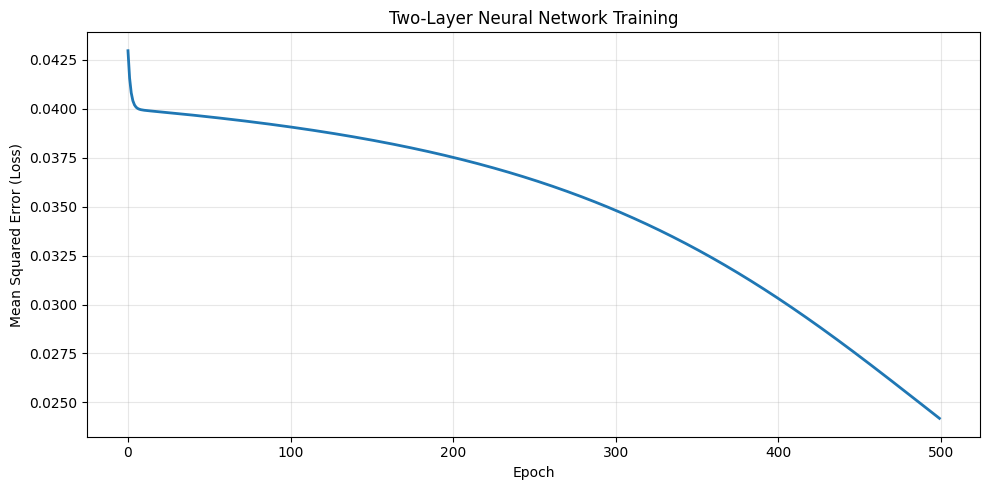

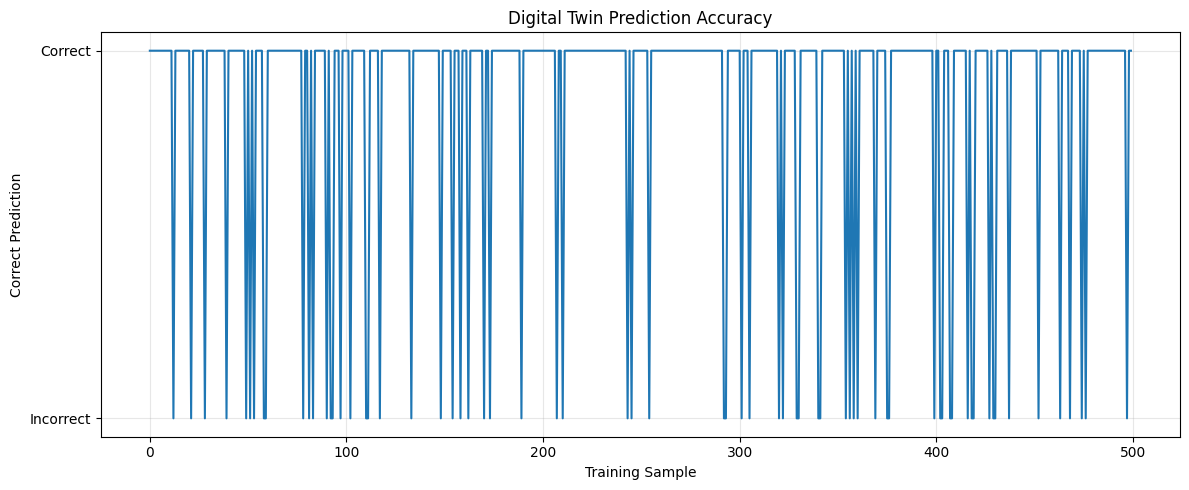

In [38]:
# YOUR CODE HERE
# Challenge: Create a better training dataset

def generate_realistic_data(n_samples=500):
    """
    Generate more realistic training data for digital twin.

    Pattern rules:
    - Social activity higher on weekends
    - Time of day matters (evening > morning)
    - Good weather increases probability
    - Good mood increases probability
    """

    # Generate random input data
    X = np.random.rand(n_samples, 4)

    # Extract individual features
    day = X[:, 0]
    time = X[:, 1]
    weather = X[:, 2]
    mood = X[:, 3]

    # Calculate social activity probability
    probability = (
        0.35 * (day > 0.7) +
        0.25 * time +
        0.20 * weather +
        0.20 * mood
    )

    # Add some random noise
    probability += np.random.normal(0, 0.05, n_samples)

    # Keep probability between 0 and 1
    probability = np.clip(probability, 0, 1)

    # Convert target into column format
    y = probability.reshape(-1, 1)

    return X, y


# Generate training data
X_train, y_train = generate_realistic_data(500)

print("Training data shape:", X_train.shape)
print("Target data shape:", y_train.shape)


# Test different architectures
architectures = [
    (4, 4, 1),   # Small
    (4, 8, 1),   # Medium (original)
    (4, 16, 1),  # Large
]

for input_size, hidden_size, output_size in architectures:
    print(f"\nTesting architecture: {input_size}-{hidden_size}-{output_size}")

    model = SimpleNeuralNetwork(input_size, hidden_size, output_size)
    model.train(X_train, y_train, epochs=500, learning_rate=0.5)

    print(f"Final loss: {model.loss_history[-1]:.4f}")


# Test different learning rates
learning_rates = [0.01, 0.1, 0.5, 1.0]

for learning_rate in learning_rates:
    print(f"\nTesting learning rate: {learning_rate}")

    model = SimpleNeuralNetwork(4, 8, 1)
    model.train(
        X_train,
        y_train,
        epochs=500,
        learning_rate=learning_rate
    )

    print(f"Final loss: {model.loss_history[-1]:.4f}")


class TwoLayerNeuralNetwork:
    """A neural network with two hidden layers."""

    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        # Initialize weights
        self.W1 = np.random.randn(input_size, hidden1_size) * 0.5
        self.b1 = np.zeros((1, hidden1_size))

        self.W2 = np.random.randn(hidden1_size, hidden2_size) * 0.5
        self.b2 = np.zeros((1, hidden2_size))

        self.W3 = np.random.randn(hidden2_size, output_size) * 0.5
        self.b3 = np.zeros((1, output_size))

        self.loss_history = []

    def forward(self, X):
        """Forward pass through both hidden layers."""

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3)

        return self.a3

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass through both hidden layers."""

        m = X.shape[0]

        # Output layer gradients
        dz3 = output - y
        dW3 = np.dot(self.a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Second hidden layer gradients
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * self.a2 * (1 - self.a2)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # First hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3

        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""

        for epoch in range(epochs):

            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create two-hidden-layer network

two_layer_nn = TwoLayerNeuralNetwork(
    input_size=4,
    hidden1_size=8,
    hidden2_size=4,
    output_size=1
)

print("Training two-hidden-layer neural network...\n")

two_layer_nn.train(
    X_train,
    y_train,
    epochs=500,
    learning_rate=0.5
)

print(f"\nFinal loss: {two_layer_nn.loss_history[-1]:.4f}")

# ============================================
# COMPARE PREDICTIONS AND CALCULATE ACCURACY
# ============================================

# Make predictions
predictions = two_layer_nn.predict(X_train)

# Convert probabilities into binary predictions
predicted_classes = (predictions >= 0.5).astype(int)

# Convert actual values into binary classes
actual_classes = (y_train >= 0.5).astype(int)

# Calculate prediction accuracy
accuracy = np.mean(
    predicted_classes == actual_classes
)

print(
    f"\nFinal loss: "
    f"{two_layer_nn.loss_history[-1]:.4f}"
)

print(
    f"Prediction accuracy: "
    f"{accuracy:.2%}"
)


# ============================================
# VISUALIZATION 1: TRAINING LOSS
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    two_layer_nn.loss_history,
    linewidth=2
)

plt.title(
    "Two-Layer Neural Network Training"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error (Loss)"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================
# VISUALIZATION 2: PREDICTION ACCURACY
# ============================================

correct_predictions = (
    predicted_classes.flatten()
    ==
    actual_classes.flatten()
)

accuracy_values = correct_predictions.astype(int)


plt.figure(figsize=(12, 5))

plt.plot(
    accuracy_values,
    linewidth=1.5
)

plt.title(
    "Digital Twin Prediction Accuracy"
)

plt.xlabel(
    "Training Sample"
)

plt.ylabel(
    "Correct Prediction"
)

plt.yticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

---
## Part 3: Connecting to LLMs

How does this relate to Large Language Models?

### 3.1 From Activities to Words

LLMs work exactly like our activity predictor, but with words!

Given text: I love coding in Python because it is

Predicted next word probabilities:
  fun: 29.10%
  clear: 21.67%
  elegant: 12.69%
  easy: 12.10%
  versatile: 9.54%
  simple: 9.53%
  powerful: 5.37%


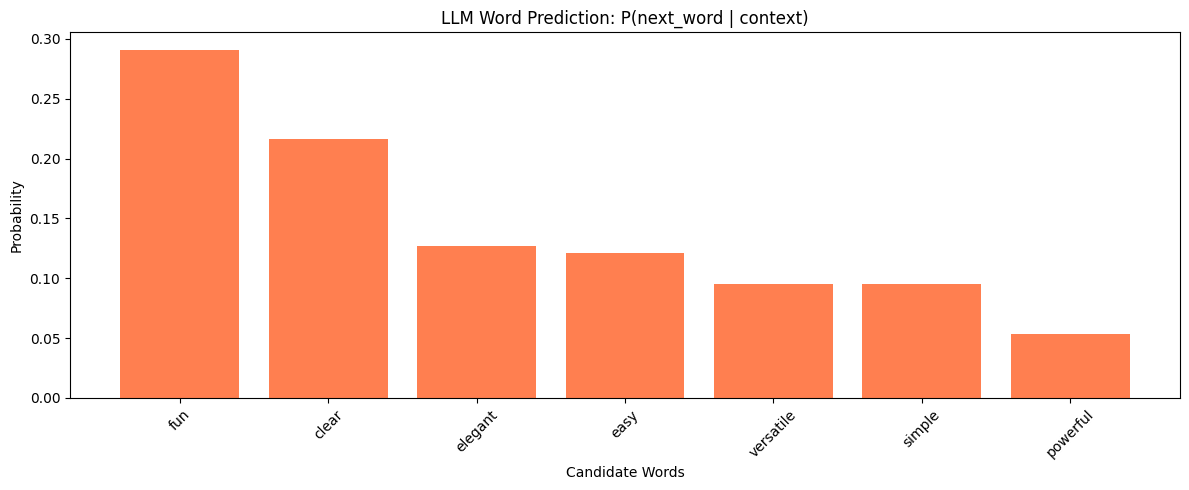

In [39]:
# Simple word prediction example
text_sequence = "I love coding in Python because it is"
words = text_sequence.split()

# Simulate word prediction
word_vocab = ['fun', 'easy', 'powerful', 'versatile', 'simple', 'clear', 'elegant']
word_probs = np.random.rand(len(word_vocab))
word_probs = word_probs / word_probs.sum()  # Normalize to probabilities

# Create probability distribution
word_dist = dict(zip(word_vocab, word_probs))
word_dist = dict(sorted(word_dist.items(), key=lambda x: x[1], reverse=True))

print("Given text:", text_sequence)
print("\nPredicted next word probabilities:")
for word, prob in word_dist.items():
    print(f"  {word}: {prob:.2%}")

# Visualize
plt.figure(figsize=(12, 5))
plt.bar(word_dist.keys(), word_dist.values(), color='coral')
plt.title('LLM Word Prediction: P(next_word | context)')
plt.ylabel('Probability')
plt.xlabel('Candidate Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Exercise 3.1 (Conceptual): Understanding LLMs

**Questions**:
1. How is predicting the next word similar to predicting the next activity?
2. What role does probability play in both cases?
3. Why might an LLM sometimes generate unexpected words?
4. How does context (previous words) help make better predictions?

Write your answers in the cell below:

**Your Answers:**

1. Similarity between word and activity prediction:
   - Both use previous information or context to predict what is most likely to happen next. An LLM predicts the next word based on previous words, while an activity model predicts the next activity based on previous activities and patterns.


2. Role of probability:
   - Probability helps determine which outcome is most likely. Both systems assign probabilities to possible next words or activities and use those probabilities to make a prediction.


3. Unexpected generations:
   - An LLM can generate unexpected words because it considers multiple possible outcomes and does not always choose the highest-probability word. Randomness, context, and the probability distribution can influence the result.


4. Importance of context:
   - Previous words provide information about the topic, meaning, and structure of a sentence. More relevant context helps the LLM understand what is being discussed and make a more accurate prediction about what should come next.

---
## Summary & Key Takeaways

### What We Learned:
1. **Probability**: AI predicts by calculating probabilities based on historical patterns
2. **Conditional Probability**: Context matters - knowing what came before improves predictions
3. **Neural Networks**: Learn patterns by adjusting weights through training
4. **Digital Twin**: Can model behaviors using probabilistic predictions
5. **LLM Connection**: Language models are sophisticated versions of these basic concepts

### Next Steps:
In the next notebook, we'll explore:
- How LLMs represent words (embeddings)
- Transformer architecture
- Attention mechanisms
- Building a simple language model for your digital twin

---
## 🏆 Challenge Project (Advanced)

**Build Your Own Digital Twin Predictor**

Create a system that:
1. Collects data about your daily patterns (sleep, activities, mood, etc.)
2. Trains a neural network to predict your next likely activity
3. Evaluates prediction accuracy
4. Visualizes patterns it learned

**Bonus**: Add temporal features (day of week, time of day) and see how they improve predictions!

Training samples: 800
Testing samples: 200
Features per sample: 5

Training Digital Twin...
Epoch 0, Loss: 1.7532
Epoch 100, Loss: 1.3536
Epoch 200, Loss: 1.2641
Epoch 300, Loss: 1.1700
Epoch 400, Loss: 1.0910
Epoch 500, Loss: 1.0316
Epoch 600, Loss: 0.9828
Epoch 700, Loss: 0.9392
Epoch 800, Loss: 0.8991
Epoch 900, Loss: 0.8619

Final loss: 0.8275

Test prediction accuracy: 69.00%

Scenario Predictions

Friday evening, good mood
Predicted next activity: Social
 Sleep: 12.74%
 Work: 16.83%
 Exercise: 21.35%
 Social: 29.49%
 Leisure: 19.59%

Monday morning, high energy
Predicted next activity: Work
 Sleep: 14.47%
 Work: 67.64%
 Exercise: 4.50%
 Social: 0.49%
 Leisure: 12.90%

Saturday afternoon, good mood
Predicted next activity: Social
 Sleep: 13.12%
 Work: 19.31%
 Exercise: 25.37%
 Social: 26.85%
 Leisure: 15.34%

Late night, tired
Predicted next activity: Leisure
 Sleep: 16.88%
 Work: 2.79%
 Exercise: 0.79%
 Social: 9.73%
 Leisure: 69.81%


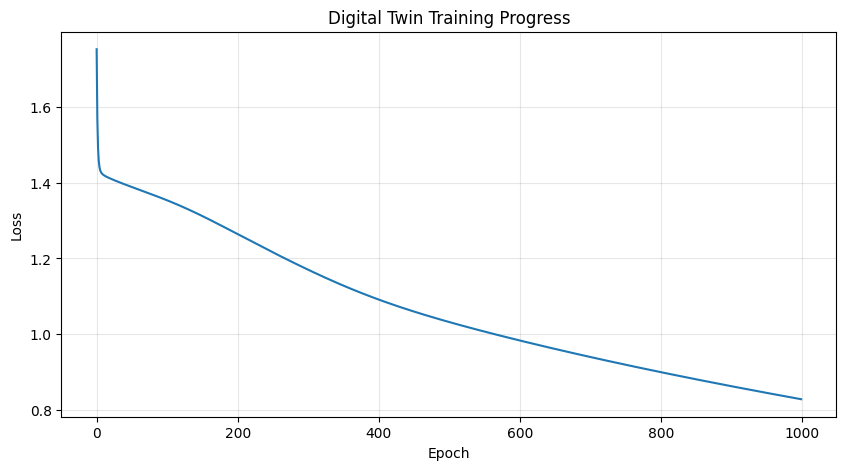

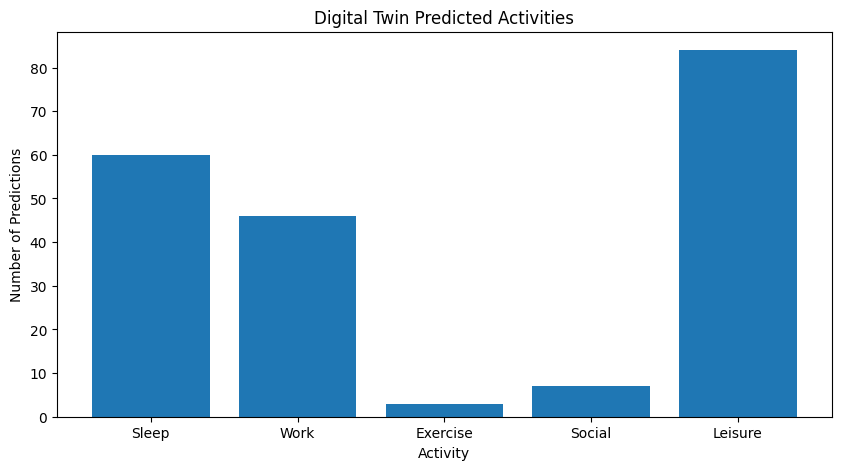

In [51]:
# YOUR CHALLENGE PROJECT CODE HERE
# This is your space to be creative!

# ============================================
# DIGITAL TWIN PREDICTOR
# ============================================

import numpy as np
import matplotlib.pyplot as plt

activity_names = {
    0: "Sleep",
    1: "Work",
    2: "Exercise",
    3: "Social",
    4: "Leisure"
}

np.random.seed(42)


# ============================================
# 1. GENERATE REALISTIC DIGITAL TWIN DATA
# ============================================

def generate_digital_twin_data(n_samples=1000):

    # Generate realistic features
    sleep = np.random.uniform(4, 10, n_samples)       # Hours of sleep
    mood = np.random.rand(n_samples)                  # 0-1
    energy = np.random.rand(n_samples)                # 0-1
    day = np.random.randint(0, 7, n_samples)          # 0=Monday, 6=Sunday
    time = np.random.randint(0, 24, n_samples)        # Hour of day

    y = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):

        # Late night / very early morning -> Sleep
        if time[i] >= 22 or time[i] < 7:
            y[i] = 0

        # Weekday working hours -> Work
        elif day[i] < 5 and 8 <= time[i] < 17 and energy[i] > 0.3:
            y[i] = 1

        # Good energy during daytime -> Exercise
        elif energy[i] > 0.7 and 10 <= time[i] < 19:
            y[i] = 2

        # Weekend + good mood -> Social
        elif day[i] >= 5 and mood[i] > 0.6 and 11 <= time[i] < 22:
            y[i] = 3

        # Poor sleep / low energy -> Leisure
        elif sleep[i] < 5.5 or energy[i] < 0.3:
            y[i] = 4

        # Good mood in evening -> Social
        elif mood[i] > 0.7 and 17 <= time[i] < 22:
            y[i] = 3

        # Default
        else:
            y[i] = 4

    # Normalize features to 0-1
    X = np.column_stack([
        sleep / 10,
        mood,
        energy,
        day / 6,
        time / 23
    ])

    return X, y


# Generate dataset
X_all, y_all = generate_digital_twin_data(1000)


# ============================================
# 2. TRAIN / TEST SPLIT
# ============================================

split = int(0.8 * len(X_all))

X_train = X_all[:split]
y_train = y_all[:split]

X_test = X_all[split:]
y_test = y_all[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Features per sample:", X_train.shape[1])


# ============================================
# 3. DIGITAL TWIN NEURAL NETWORK
# ============================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class DigitalTwinNetwork:

    def __init__(self, input_size, hidden_size, output_size):

        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        self.loss_history = []


    def softmax(self, z):

        exp_z = np.exp(
            z - np.max(z, axis=1, keepdims=True)
        )

        return exp_z / np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )


    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2


    def train(self, X, y, epochs=1000, learning_rate=0.5):

        y_encoded = np.eye(
            self.b2.shape[1]
        )[y]

        for epoch in range(epochs):

            output = self.forward(X)

            loss = -np.mean(
                np.sum(
                    y_encoded * np.log(output + 1e-8),
                    axis=1
                )
            )

            self.loss_history.append(loss)

            # Backpropagation
            m = X.shape[0]

            dz2 = output - y_encoded

            dW2 = np.dot(
                self.a1.T,
                dz2
            ) / m

            db2 = np.sum(
                dz2,
                axis=0,
                keepdims=True
            ) / m

            da1 = np.dot(
                dz2,
                self.W2.T
            )

            dz1 = (
                da1 *
                self.a1 *
                (1 - self.a1)
            )

            dW1 = np.dot(
                X.T,
                dz1
            ) / m

            db1 = np.sum(
                dz1,
                axis=0,
                keepdims=True
            ) / m

            # Update weights
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2

            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1

            if epoch % 100 == 0:

                print(
                    f"Epoch {epoch}, Loss: {loss:.4f}"
                )


    def predict(self, X):

        probabilities = self.forward(X)

        return np.argmax(
            probabilities,
            axis=1
        )


    def predict_probabilities(self, X):

        return self.forward(X)


# ============================================
# 4. TRAIN THE DIGITAL TWIN
# ============================================

print("\nTraining Digital Twin...")

digital_twin = DigitalTwinNetwork(
    input_size=5,
    hidden_size=8,
    output_size=5
)

digital_twin.train(
    X_train,
    y_train,
    epochs=1000,
    learning_rate=0.5
)


# ============================================
# 5. FINAL LOSS
# ============================================

print(
    f"\nFinal loss: "
    f"{digital_twin.loss_history[-1]:.4f}"
)


# ============================================
# 6. TEST ACCURACY
# ============================================

predictions = digital_twin.predict(X_test)

accuracy = np.mean(
    predictions == y_test
)

print(
    f"\nTest prediction accuracy: "
    f"{accuracy:.2%}"
)


# ============================================
# 7. TEST REALISTIC SCENARIOS
# ============================================

scenarios = [

    (
        "Friday evening, good mood",
        7,      # sleep hours
        0.9,    # mood
        0.8,    # energy
        4,      # Friday
        19      # 7 PM
    ),

    (
        "Monday morning, high energy",
        7,
        0.7,
        0.9,
        0,
        9
    ),

    (
        "Saturday afternoon, good mood",
        8,
        0.9,
        0.8,
        5,
        14
    ),

    (
        "Late night, tired",
        5,
        0.5,
        0.2,
        3,
        23
    )
]


print("\nScenario Predictions")
print("=" * 40)


for name, sleep, mood, energy, day, time in scenarios:

    scenario_input = np.array([[
        sleep / 10,
        mood,
        energy,
        day / 6,
        time / 23
    ]])

    prediction = digital_twin.predict(
        scenario_input
    )[0]

    probabilities = digital_twin.predict_probabilities(
        scenario_input
    )[0]

    print(f"\n{name}")

    print(
        f"Predicted next activity: "
        f"{activity_names[prediction]}"
    )

    for activity, probability in zip(
        activity_names.values(),
        probabilities
    ):

        print(
            f" {activity}: "
            f"{probability:.2%}"
        )


# ============================================
# 8. TRAINING LOSS VISUALIZATION
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    digital_twin.loss_history
)

plt.title(
    "Digital Twin Training Progress"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================
# 9.PREDICTED ACTIVITIES VISUALIZATION
# ============================================

predicted_counts = np.bincount(
    predictions,
    minlength=len(activity_names)
)

plt.figure(figsize=(10, 5))

plt.bar(
    activity_names.values(),
    predicted_counts
)

plt.title("Digital Twin Predicted Activities")
plt.xlabel("Activity")
plt.ylabel("Number of Predictions")

plt.show()
